# **TELECOM X PARTE 2 - PREDICCIÓN DE CANCELACIÓN CHURN📉**

## **🛠️ Preparación de los Datos**

**Instalamos la biblioteca [pandas](https://pandas.pydata.org/) para realizar el análisis de datos**

In [99]:
%pip install -r /content/Requeriments.txt

**Asignacion de alias a librerías**

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Se importó pandas para realizar la extracción desde el archivo cargado en el entorno de trabajo, para el análisis y visualización de los datos. En conjunto de [IPython.display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display) módulo con su función principal [display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display).Permitiendo mostrar un objeto Python, determinando automáticamente la mejor representación para el objeto**

In [101]:
import pandas as pd
from IPython.display import display


try:
    #Cargamos los datos
    datos = '/content/Analisis_Telecom_X_Limpio_y_Transformado'
    df_telecomx = pd.read_csv(datos)

except Exception as e:
    # Archivo no cargado en el entorno de trabajo
    print(f'Error al extraer los datos: {e}')

else:
    # Usamos display() para ver el DataFrame formateado si no hay error
    pd.set_option('display.max_columns', None)
    display(df_telecomx.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total
0,0002-ORFBO,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0003-MKNFE,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,0004-TLHLJ,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,0011-IGKFF,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,0013-EXCHZ,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


**Eliminamos la columna CustomerID, ya que para los modelos de predicción esta columna no aporta valor o puede afectar al mismo**

In [102]:
try:
    #Realizamos la copia del DataFrame original
    df_telecomx_nuevo = df_telecomx.copy()

    #Eliminamos la columna innecesaria
    df_telecomx_nuevo = df_telecomx_nuevo.drop(columns='customerID')
except Exception as e:
    print(f'Error al eliminar la columna customerID: {e}')
else:
    #Mostramos el resultado
    display(df_telecomx_nuevo.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total
0,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


In [103]:
try:
  #Separamos el conjunto de Datos en 2 partes:

  # y: alamcenara la variable objetivo o interés
  y = df_telecomx_nuevo['Churn']

  # X: almacenara las variables explicativas
  X = df_telecomx_nuevo.drop(columns='Churn')
except Exception as e:
  print(f'Error al tratar la variable objetivo: {e}')
else:
  print('Cambios realizados exitosamente')

Cambios realizados exitosamente


**Utilizamos el método [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) de la biblioteca de aprendizaje automático [Scikit-learn](https://scikit-learn.org/) para tratar las variables categorías del conjunto de datos convirtiéndolas en valores numéricos para el proceso de Machine Learning, ya que los modelos de aprendizaje automático trabajan con datos numéricos.**

In [104]:
try:
    #Importamos la funciones:
    from sklearn.compose import make_column_transformer
    from sklearn.preprocessing import OneHotEncoder

    # Estructuramos la tranformacion y parametros para tratar las variables categoricas
    transfor = make_column_transformer((OneHotEncoder(drop='if_binary'),
                  ['gender','InternetService','Contract','PaymentMethod']),
                  remainder='passthrough', sparse_threshold=0, force_int_remainder_cols=False)

    # Copiamos los datos de las variables explicativas para realizar la tranformacion en un objeto independiente
    X_transfor = X.copy()

    #Variable que contiene el nombre de las columnas explicativas
    colums = X_transfor.columns

    #Realizamos el ajuste y asignacion del resultado en la tranformacion de las variables explicativas
    X_transfor = transfor.fit_transform(X_transfor)

    #Creamos DataFrame de visualización para ver el resultado de la transformación
    df_demostracion= pd.DataFrame(X_transfor,columns=transfor.get_feature_names_out(colums))

except Exception as e:
    print(f'Error al tratar las variables categorías: {e}')
else:
  #Mostramos el DataFrame para ver el tratamiento
  display(df_demostracion.head())

,onehotencoder__gender_Male,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__PhoneService,remainder__MultipleLines,remainder__PaperlessBilling,remainder__ChargesMonthly,remainder__ChargesTotal,remainder__ChargesDaily_Total
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,9.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,65.6,593.30,2.20
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,59.9,542.40,2.01
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,73.9,280.85,2.34
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,13.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,98.0,1237.85,3.17
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,83.9,267.40,2.97


**Calculamos la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evaluando si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.**

In [105]:
try:
  #Creamos variable que contiene la cantidad por tipo
  proporcion = y.value_counts()
except Exception as e:
  print(f'Error revisar la variable objetivo: {e}')
else:
  #Mostramos el resultado
  display(proporcion)


,count
Churn,
0,5376
1,1891


## **🎯 Correlación y Selección de Variables**

**Creamos gráfico para observar la correlación de cada variable en relacion con la variable objetivo: CHURN, mientras mas cerca este el valor de 1 índica mayor correlación en caso contrarió mientras más cerca de -1 este el valor menor correlación tiende a tener**

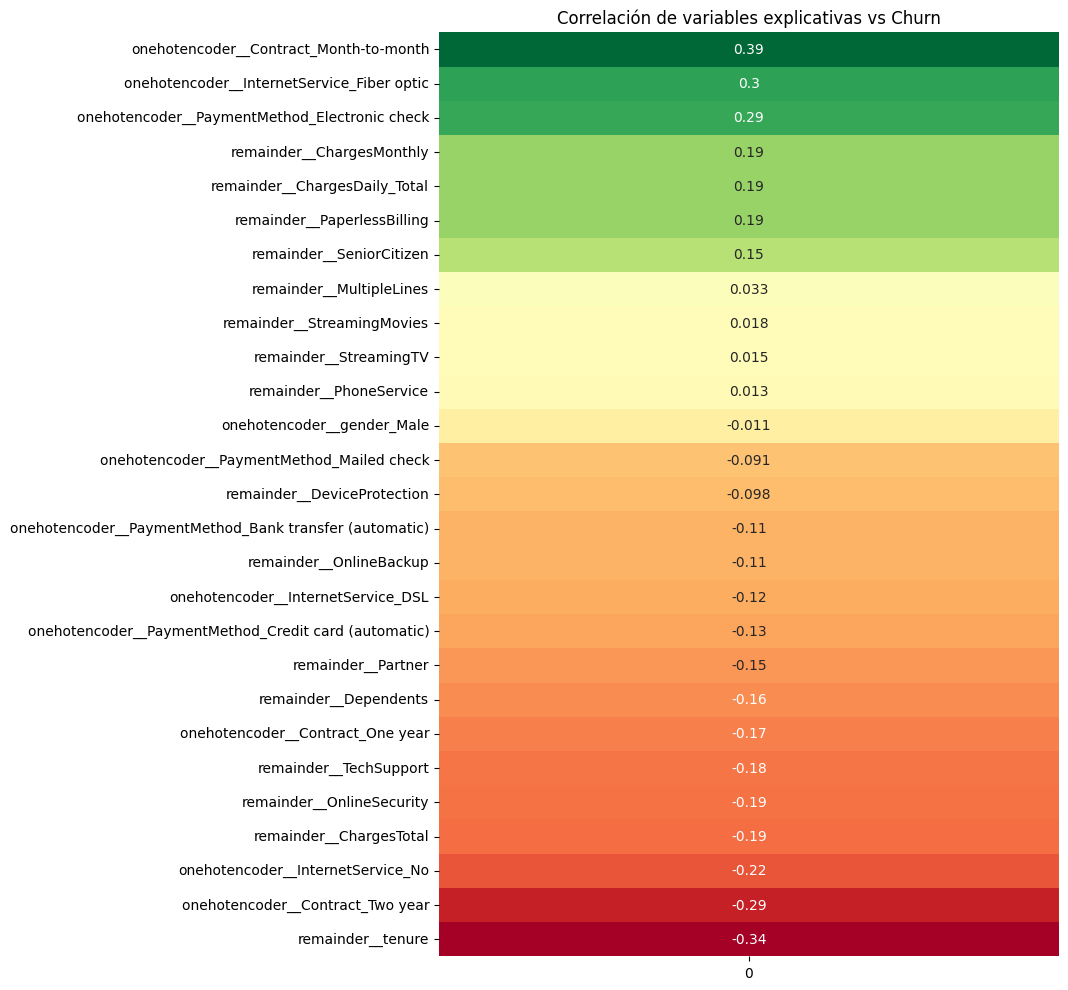

In [106]:
try:
  # creamos un nuevo DataFrame con los datos tratados con OneHotEncoder
  analisis_corr = df_demostracion.copy()

  # Analizamos la correlacion de las variables explicativas con la variable objetivo
  corr_target = analisis_corr.corrwith(y).sort_values(ascending=False)

  # Visualizamos el grafico con la correlacion
  plt.figure(figsize=(8, 12))
  sns.heatmap(corr_target.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
  plt.title('Correlación de variables explicativas vs Churn')


except Exception as e:
  print(f'Error al realizar el análisis de correlación: {e}')
else:
  plt.show()

**Realizamos el cálculo absoluto de las variables explicativas que aportan más valor al análisis y eliminando aquellas variables que no presentan un valor significativo**

In [107]:
try:
  # Calcular correlación absoluta con el target
  corr_target_abs = analisis_corr.corrwith(y).abs()

  # Definir el umbral
  umbral = 0.05

  # Definir variables relevantes
  variables_relevantes = corr_target_abs[corr_target_abs > umbral].index

  # Filtrar el DataFrame
  df_filtrado = analisis_corr[variables_relevantes]

except Exception as e:
  print(f'Error al realizar el análisis de correlación: {e}')
else:
  print(f"Variables eliminadas por baja correlación:\n {set(analisis_corr.columns) - set(variables_relevantes)}")

Variables eliminadas por baja correlación:
 {'remainder__MultipleLines', 'onehotencoder__gender_Male', 'remainder__StreamingMovies', 'remainder__StreamingTV', 'remainder__PhoneService'}


**Calculamos el factor de inflación de la varianza para determinar la presencia de Multicolinealidad, en caso de que exista tratar los datos para reducir esta**

In [108]:
try:
  # Importamos funcion para calcular la Multicolinealidad
  from statsmodels.stats.outliers_influence import variance_inflation_factor

  # Calcular VIF para cada variable explicativas

  # Creamos DataFrame
  vif_data = pd.DataFrame()

  # Columna que tendra los nombres de las columnas explicativas
  vif_data["variable"] = df_filtrado.columns

  # Columna que tendra variance_inflation_factor
  vif_data["VIF"] = [variance_inflation_factor(df_filtrado.values, i) for i in range(len(df_filtrado.columns))]

except Exception as e:
  print(f'Error al calcular VIF: {e}')
else:
  # Visualizamos el resultado
  print(vif_data.sort_values(by="VIF", ascending=False))


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                             variable         VIF
0                  onehotencoder__InternetService_DSL         inf
1          onehotencoder__InternetService_Fiber optic         inf
2                   onehotencoder__InternetService_No         inf
3              onehotencoder__Contract_Month-to-month         inf
4                    onehotencoder__Contract_One year         inf
5                    onehotencoder__Contract_Two year         inf
6   onehotencoder__PaymentMethod_Bank transfer (au...         inf
7   onehotencoder__PaymentMethod_Credit card (auto...         inf
8       onehotencoder__PaymentMethod_Electronic check         inf
9           onehotencoder__PaymentMethod_Mailed check         inf
19                          remainder__ChargesMonthly  104.083984
21                      remainder__ChargesDaily_Total   90.499771
20                            remainder__ChargesTotal   10.208079
13                                  remainder__tenure    7.163588
11        

**Realizamos una nueva transformación a los datos para comprimir la información reduciendo al mínimo la redundancia entre las variables, luego se realizó la estandarización de las variables numéricas para que los modelos de predicción que dependen de este tratamiento generalicen mejor**

In [109]:
try:

  # Importamos las funciones
  from sklearn.compose import ColumnTransformer
  from sklearn.preprocessing import OneHotEncoder,StandardScaler

  # Creamos las variables con las columnas categóricas y numéricas
  categorical_features = ['InternetService', 'Contract', 'PaymentMethod', 'gender']
  numeric_features = ['tenure', 'ChargesMonthly', 'ChargesTotal', 'ChargesDaily_Total']

  # Estructuramos la tranformacion y parametros para tratar las variables
  transformer = ColumnTransformer(transformers=[
  ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
  ('num', StandardScaler(), numeric_features)],
  remainder='passthrough' # Mantiene el resto de columnas si las hay
  )

  # Copiamos los datos de las variables explicativas para realizar la tranformacion en un objeto independiente
  X_transformer = X.copy()

  # Ajustar y transformar las variables explicativas
  X_procesado = transformer.fit_transform(X_transformer)

  # Creamos variable con los nombres de las columnas transformadas
  encoded_cols = transformer.get_feature_names_out(X_transformer.columns)

  # Creamos DataFrame con las datos transformados y estandarizados
  X_final = pd.DataFrame(X_procesado, columns=encoded_cols)

  # Eliminamos las columnas que causan el ruido matemático
  X_final = X_final.drop(columns=['num__ChargesDaily_Total', 'num__ChargesTotal','num__ChargesMonthly', 'remainder__PhoneService'])

except Exception as e:
  print(f'Error al tratar las variables: {e}')
else:
  # Mostramos como quedo el resultado
  X_final.head()

**Calculamos nuevamente con la transformación y estandarización realizada el factor de inflación de la varianza para determinar la presencia de Multicolinealidad, en caso de que exista tratar los datos para reducir esta**

In [110]:
try:
  # Importamos funcion para calcular la Multicolinealidad
  from statsmodels.stats.outliers_influence import variance_inflation_factor

  # Calcular VIF para cada variable explicativas

  # Creamos DataFrame
  vif_data_2 = pd.DataFrame()

  # Columna que tendra los nombres de las columnas explicativas
  vif_data_2["variable"] = X_final.columns

  # Columna que tendra variance_inflation_factor
  vif_data_2["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(len(X_final.columns))]

except Exception as e:
  print(f'Error al calcular VIF: {e}')
else:
  # Visualizamos el resultado
  print(vif_data_2.sort_values(by="VIF", ascending=False))

                                      variable       VIF
3                       cat__Contract_Two year  3.170238
0             cat__InternetService_Fiber optic  2.784989
10                          remainder__Partner  2.729444
19                 remainder__PaperlessBilling  2.653092
17                  remainder__StreamingMovies  2.443435
5          cat__PaymentMethod_Electronic check  2.442447
16                      remainder__StreamingTV  2.413665
8                                  num__tenure  2.346375
18                    remainder__MultipleLines  2.249843
14                 remainder__DeviceProtection  2.077709
6              cat__PaymentMethod_Mailed check  2.035223
1                      cat__InternetService_No  1.973856
11                       remainder__Dependents  1.964487
15                      remainder__TechSupport  1.911025
13                     remainder__OnlineBackup  1.910903
2                       cat__Contract_One year  1.907349
7                             c

**Creamos nuevamente el gráfico dónde observamos la correlación de cada variable en relacion con la variable objetivo: CHURN, mientras mas cerca este el valor de 1 índica mayor correlación en caso contrarió mientras más cerca de -1 este el valor menor correlación tiende a tener**

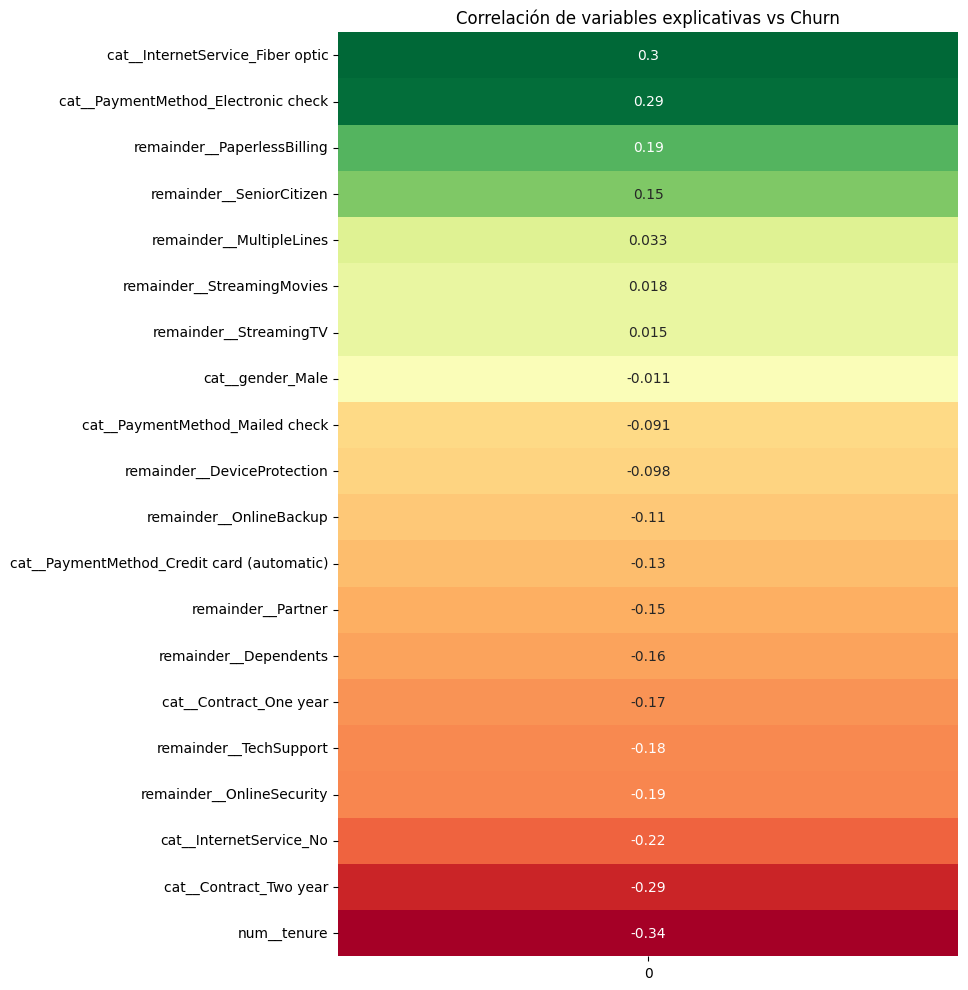

In [111]:
try:

  # Analizamos la correlacion de las variables explicativas con la variable objetivo
  corr_final = X_final.corrwith(y).sort_values(ascending=False)

  # Visualizamos el grafico con la correlacion
  plt.figure(figsize=(8, 12))
  sns.heatmap(corr_final.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
  plt.title('Correlación de variables explicativas vs Churn')

except Exception as e:
  print(f'Error al realizar el análisis de correlación: {e}')
else:
  plt.show()

**Realizamos nuevamente el cálculo absoluto de las variables explicativas que aportan más valor al análisis y eliminando aquellas variables que no presentan un valor significativo**

In [116]:
try:

  # Calcular correlación absoluta con el target luego del nuevo tratamiento
  corr_target_abs_final = X_final.corrwith(y).abs()

  # Definir el umbral
  umbral_final = 0.05

  # Definir variables relevantes
  variables_relevantes_final = corr_target_abs_final[corr_target_abs_final > umbral_final].index

  # Filtrar el DataFrame
  X_champions = X_final[variables_relevantes_final]

except Exception as e:
  print(f'Error al realizar el análisis de correlación: {e}')
else:
  print(f"Variables eliminadas por baja correlación:\n {set(X_final.columns) - set(variables_relevantes_final)}")
  print('\n')
  display(X_champions.head())


Variables eliminadas por baja correlación:
 {'remainder__StreamingMovies', 'cat__gender_Male', 'remainder__StreamingTV', 'remainder__MultipleLines'}




,cat__InternetService_Fiber optic,cat__InternetService_No,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,num__tenure,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__PaperlessBilling
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.950200,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.950200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.153700,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.787401,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.194400,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
